# STATE SE — Shendure 59k cells, quality 1.0

Prepare data, train, embed, and compute LMI (author_day signal).

In [14]:
import sys, os
sys.path.insert(0, os.path.expanduser(
    "~/noise_scaling/modeling/Scaling-up-measurement-noise-scaling-laws/scaling_laws/src"
))

from pathlib import Path
import glob
import numpy as np
import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import umap

from scaling_laws.prepare.data import Experiments, PrepareData
from scaling_laws.algo import State

In [15]:
DATA_DIR = Path(os.path.expanduser("~/noise_scaling/data"))
DATASET = "shendure"
SIZE = 59_948
QUALITY = 1.0
DEVICE = 0
SEED = 42

In [16]:
# --- Gene count check: raw dataset vs ESM embeddings ---
import torch

raw_path = DATA_DIR / DATASET / "raw" / "raw.h5ad"
adata_raw = ad.read_h5ad(raw_path, backed="r")
raw_genes = set(adata_raw.var_names)
n_raw = len(raw_genes)
adata_raw.file.close()

esm_emb = torch.load(DATA_DIR / "other" / "esm" / "merged_esm_embeddings.pt", map_location="cpu")
esm_genes = set(esm_emb.keys())
n_esm = len(esm_genes)
del esm_emb

overlap = len(raw_genes & esm_genes)
print(f"{DATASET}: {overlap}/{n_raw} raw genes found in ESM ({100*overlap/n_raw:.1f}%), ESM total: {n_esm}")

shendure: 21820/45525 raw genes found in ESM (47.9%), ESM total: 61260


## 1. Prepare STATE data

Run `state emb preprocess` to build the gene-embedding profile.

In [17]:
experiments = Experiments(
    path_to_data_dir=str(DATA_DIR),
    datasets=[DATASET],
    qualities=[QUALITY],
    sizes=[SIZE],
    algos=["State"],
    signal_columns=["author_day"],
    device=DEVICE,
)

experiments.prepare_state_data()

  Using ESM embeddings: /home/igor/noise_scaling/data/other/esm/merged_esm_embeddings.pt

=== Preparing State data for shendure / 59948 / 1.0 ===
  State train manifest: /home/igor/noise_scaling/data/shendure/59948/1.0/preprocessed/state_data/train.csv
  State val manifest: /home/igor/noise_scaling/data/shendure/validation/1.0/preprocessed/state_data/val.csv
  State test manifest: /home/igor/noise_scaling/data/shendure/test/1.0/preprocessed/state_data/test.csv
  Running: /home/igor/miniconda3/envs/state/bin/python -m state emb preprocess --profile-name scaling_shendure_59948_1_0 --train-csv /home/igor/noise_scaling/data/shendure/59948/1.0/preprocessed/state_data/train.csv --val-csv /home/igor/noise_scaling/data/shendure/59948/1.0/preprocessed/state_data/val_combined.csv --output-dir /home/igor/noise_scaling/data/shendure/59948/1.0/preprocessed/state_data --config-file /home/igor/noise_scaling/data/shendure/59948/1.0/preprocessed/state_data/state_config.yaml --all-embeddings /home/igor/

2026-04-14 02:11:27,713 INFO: Loading existing embeddings from /home/igor/noise_scaling/data/other/esm/merged_esm_embeddings.pt
2026-04-14 02:11:30,880 INFO: Loading training and validation CSV files...
2026-04-14 02:11:30,885 INFO: Processing 1 training datasets and 2 validation datasets...
2026-04-14 02:11:30,890 INFO: Scanning datasets serially...
Scanning datasets: 100%|██████████| 3/3 [00:20<00:00,  6.92s/it]
2026-04-14 02:11:51,648 INFO: Found 45525 unique genes across datasets
2026-04-14 02:11:53,168 INFO: Saved embeddings to /home/igor/noise_scaling/data/shendure/59948/1.0/preprocessed/state_data/all_embeddings_scaling_shendure_59948_1_0.pt
2026-04-14 02:11:53,226 INFO: Saved dataset mapping to /home/igor/noise_scaling/data/shendure/59948/1.0/preprocessed/state_data/ds_emb_mapping_scaling_shendure_59948_1_0.torch
2026-04-14 02:11:53,227 INFO: Saved valid gene masks to /home/igor/noise_scaling/data/shendure/59948/1.0/preprocessed/state_data/valid_genes_masks_scaling_shendure_599

  Config patched: val uses val-only (no test leakage)
  Profile saved to /home/igor/noise_scaling/data/shendure/59948/1.0/preprocessed/state_data


In [18]:
# Verify: list the generated state_data/ contents
state_data = DATA_DIR / DATASET / str(SIZE) / str(QUALITY) / "preprocessed" / "state_data"
print(f"Profile dir: {state_data}")
for f in sorted(state_data.iterdir()):
    size_mb = f.stat().st_size / 1e6 if f.is_file() else 0
    print(f"  {f.name:60s}  {size_mb:.2f} MB" if f.is_file() else f"  {f.name}/")

# Also check val / test state_data dirs were created
for split in ["validation", "test"]:
    sd = DATA_DIR / DATASET / split / str(QUALITY) / "preprocessed" / "state_data"
    print(f"\n{split} state_data: {sd}  (exists={sd.exists()})")
    if sd.exists():
        for f in sorted(sd.iterdir()):
            print(f"  {f.name}")

Profile dir: /home/igor/noise_scaling/data/shendure/59948/1.0/preprocessed/state_data
  all_embeddings_scaling_shendure_59948_1_0.pt                  249.21 MB
  ds_emb_mapping_scaling_shendure_59948_1_0.torch               1.10 MB
  state_config.yaml                                             0.01 MB
  train.csv                                                     0.00 MB
  train_scaling_shendure_59948_1_0.csv                          0.00 MB
  val_combined.csv                                              0.00 MB
  val_only.csv                                                  0.00 MB
  val_only_scaling_shendure_59948_1_0.csv                       0.00 MB
  val_scaling_shendure_59948_1_0.csv                            0.00 MB
  valid_genes_masks_scaling_shendure_59948_1_0.torch            0.14 MB

validation state_data: /home/igor/noise_scaling/data/shendure/validation/1.0/preprocessed/state_data  (exists=True)
  val.csv

test state_data: /home/igor/noise_scaling/data/shendure/test/1.0

## 2. Train

In [19]:
base_dir = DATA_DIR / DATASET / str(SIZE) / str(QUALITY)

model = State(
    base_dir=str(base_dir),
    device=DEVICE,
    max_epochs=100,
    early_stopping_patience=3,
    dataset_name=DATASET,
    seed=SEED,
)

print(f"Train:      {model.train_data_path / 'preprocessed.h5ad'}")
print(f"Validation: {model.validation_data_path / 'preprocessed.h5ad'}")
print(f"Test:       {model.test_data_path / 'preprocessed.h5ad'}")
print(f"Profile:    {model.profile_dir}")
print(f"Config:     {model.config_path}")

Using GPU 0 (visible as cuda:0)
Train:      /home/igor/noise_scaling/data/shendure/59948/1.0/preprocessed/preprocessed.h5ad
Validation: /home/igor/noise_scaling/data/shendure/validation/1.0/preprocessed/preprocessed.h5ad
Test:       /home/igor/noise_scaling/data/shendure/test/1.0/preprocessed/preprocessed.h5ad
Profile:    /home/igor/noise_scaling/data/shendure/59948/1.0/preprocessed/state_data
Config:     /home/igor/noise_scaling/data/shendure/59948/1.0/preprocessed/state_data/state_config.yaml


In [20]:
model.train()

  Data: 59948 cells, ~468 batches/epoch, val every 468 steps
  Running: /home/igor/miniconda3/envs/state/bin/python -m state emb fit --conf /home/igor/noise_scaling/data/shendure/59948/1.0/preprocessed/state_data/state_config.yaml embeddings.current=scaling_shendure_59948_1_0 dataset.current=scaling_shendure_59948_1_0 dataset.num_cells=59948 dataset.num_train_workers=4 dataset.num_val_workers=2 dataset.pad_length=512 dataset.P=128 dataset.N=128 dataset.S=128 model.batch_size=128 model.emsize=256 model.d_hid=512 model.nhead=4 model.nlayers=3 model.output_dim=256 model.dataset_correction=false model.dropout=0.1 optimizer.max_lr=5.0e-04 optimizer.gradient_accumulation_steps=1 optimizer.weight_decay=0.01 experiment.name=state_scaling_shendure_59948_1_0 experiment.num_epochs=100 experiment.num_gpus_per_node=1 experiment.num_nodes=1 experiment.port=54795 experiment.val_check_interval=468 experiment.limit_val_batches=50 experiment.checkpoint.path=/home/igor/noise_scaling/data/shendure/59948/1

Using bfloat16 Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA A100-SXM4-40GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
Loading `train_dataloader` to estimate number of stepping batches.


┏━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                ┃ Type                    ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder             │ Sequential              │  656 K │ train │     0 │
│ 1 │ transformer_encoder │ FlashTransformerEncoder │  1.6 M │ train │     0 │
│ 2 │ decoder             │ Sequential              │  329 K │ train │     0 │
│ 3 │ binary_decoder      │ Sequential              │  2.1 M │ train │     0 │
│ 4 │ bin_encoder         │ Embedding               │  2.6 K │ train │     0 │
│ 5 │ count_encoder       │ Sequential              │  6.2 K │ train │     0 │
│ 6 │ pe_embedding        │ Embedding               │  109 M │ train │     0 │
│   │ other params        │ n/a                     │  2.6 K │ n/a   │   n/a │
└───┴─────────────────────┴─────────────────────────┴────────┴───────┴───────┘
Trainable params: 4.7 M                             

Metric validation/val_loss improved. New best score: 11.313


Epoch 1/99 ━━━━━━━━━━━━━━━━━━━━╸ 468/469 0:01:55 • 0:00:01 2.92it/s v_num: 0.0000.000
Epoch 1/99 ━━━━━━━━━━━━━━━━━━━╸ 468/469 0:01:55 • 0:00:01 2.92it/s  v_num: 0.000
Epoch 1/99 ━━━━━━━━━━━━━━━━━━━━╸ 468/469 0:01:56 • 0:00:01 2.92it/s v_num: 0.000
Epoch 1/99 ━━━━━━━━━━━━━━━━━━━━╸ 468/469 0:01:56 • 0:00:01 2.92it/s v_num: 0.000
Epoch 1/99 ━━━━━━━━━━━━━━━━━━━━╸ 468/469 0:01:57 • 0:00:01 2.92it/s v_num: 0.000
Epoch 1/99 ━━━━━━━━━━━━━━━━━━━━╸ 468/469 0:01:57 • 0:00:01 2.92it/s v_num: 0.000
Epoch 1/99 ━━━━━━━━━━━━━━━━━━━━╸ 468/469 0:01:58 • 0:00:01 2.92it/s v_num: 0.000
Epoch 2/99 ━━━━━━━━━━━━━━━━━━━━━━━ 0/469 0:01:58 • 0:00:01 0.00it/s v_num: 0.000mv_num: 0.000

...

Epoch 9/99 ━━━━━━━━━━━━━━━━━━━╸ 468/469 0:02:21 • 0:00:01 10.95it/s v_num: 0.0000.000
Epoch 9/99 ━━━━━━━━━━━━━━━━━━━╸ 468/469 0:02:21 • 0:00:01 10.95it/s v_num: 0.000
Epoch 9/99 ━━━━━━━━━━━━━━━━━━━╸ 468/469 0:02:22 • 0:00:01 10.95it/s v_num: 0.000
Epoch 9/99 ━━━━━━━━━━━━━━━━━━━╸ 468/469 0:02:22 • 0:00:01 10.95it/s v_num: 0.000
Epoch 9/99 ━━━━━━━━━━━━━━━━━━━╸ 468/469 0:02:23 • 0:00:01 10.95it/s v_num: 0.000
Epoch 9/99 ━━━━━━━━━━━━━━━━━━━╸ 468/469 0:02:23 • 0:00:01 10.95it/s v_num: 0.000
Epoch 9/99 ━━━━━━━━━━━━━━━━━━━╸ 468/469 0:02:23 • 0:00:01 10.95it/s v_num: 0.000
Epoch 10/99 ━━━━━━━━━━━━━━━━━━━╸ 468/469 0:01:38 • 0:00:01 3.84it/s v_num: 0.0000.000
Epoch 10/99 ━━━━━━━━━━━━━━━━━━╸ 468/469 0:01:38 • 0:00:01 3.84it/s  v_num: 0.000
Epoch 10/99 ━━━━━━━━━━━━━━━━━━━╸ 468/469 0:01:39 • 0:00:01 3.84it/s v_num: 0.000
Epoch 10/99 ━━━━━━━━━━━━━━━━━━━╸ 468/469 0:01:39 • 0:00:01 3.84it/s v_num: 0.000
Epoch 10/99 ━━━━━━━━━━━━━━━━━━━╸ 468/469 0:01:40 • 0:00:01 3.84it/s v_num: 0.000
Epoch 10/99 ━━━━━━

Monitored metric validation/val_loss did not improve in the last 3 records. Best score: 10.241. Signaling Trainer to stop.


Epoch 11/99 ━━━━━━━━━━━━━━━━━━━╸ 468/469 0:01:39 • 0:00:01 3.84it/s v_num: 0.000


`weights_only` was not set, defaulting to `False`.


  Training complete.


## 3. Training / validation loss curves

Reading: /home/igor/noise_scaling/data/shendure/59948/1.0/results/State/model/checkpoints/state_scaling_shendure_59948_1_0/version_0/metrics.csv


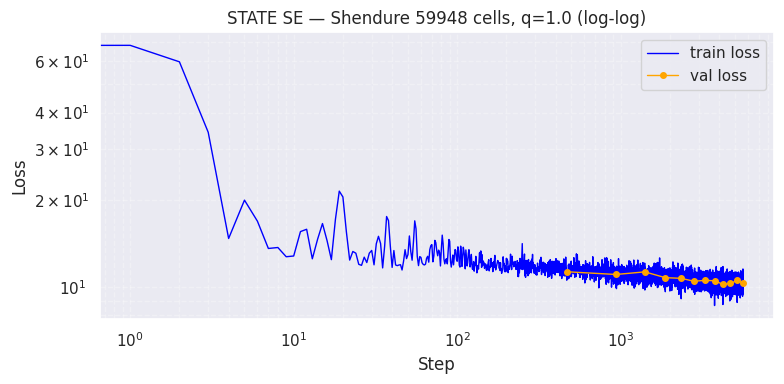

In [21]:
log_dirs = sorted(glob.glob(
    str(model.checkpoint_dir / f"state_{model.profile_name}" / "version_*")
))
metrics_file = Path(log_dirs[-1]) / "metrics.csv"
print(f"Reading: {metrics_file}")

df = pd.read_csv(metrics_file)
train_loss = df[["step", "trainer/train_loss"]].dropna()
val_loss = df[["step", "validation/val_loss"]].dropna()

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    train_loss["step"], train_loss["trainer/train_loss"],
    label="train loss", color="blue", linewidth=1
)

ax.plot(
    val_loss["step"], val_loss["validation/val_loss"],
    color="orange", marker="o", label="val loss", markersize=4, linewidth=1
)

ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title(f"STATE SE \u2014 Shendure {SIZE} cells, q={QUALITY} (log-log)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.legend()
ax.grid(True, alpha=0.3, which="both", linestyle='--')
fig.tight_layout()
plt.show()

## 4. Embed test set

In [22]:
embeddings = model.embed()
print(f"Embeddings shape: {embeddings.shape}")

  Using checkpoint: /home/igor/noise_scaling/data/shendure/59948/1.0/results/State/model/checkpoints/state_scaling_shendure_59948_1_0/exp_state_scaling_shendure_59948_1_0_layers_3_dmodel_256_samples_512_max_lr_0.0005_op_dim_256-epoch=9-step=4680.ckpt
  Running: /home/igor/miniconda3/envs/state/bin/python -m state emb transform --checkpoint /home/igor/noise_scaling/data/shendure/59948/1.0/results/State/model/checkpoints/state_scaling_shendure_59948_1_0/exp_state_scaling_shendure_59948_1_0_layers_3_dmodel_256_samples_512_max_lr_0.0005_op_dim_256-epoch=9-step=4680.ckpt --input /home/igor/noise_scaling/data/shendure/test/1.0/preprocessed/preprocessed.h5ad --output /home/igor/noise_scaling/data/shendure/59948/1.0/results/State/model/embeddings.npy


INFO:state._cli._emb._transform:Using model checkpoint: /home/igor/noise_scaling/data/shendure/59948/1.0/results/State/model/checkpoints/state_scaling_shendure_59948_1_0/exp_state_scaling_shendure_59948_1_0_layers_3_dmodel_256_samples_512_max_lr_0.0005_op_dim_256-epoch=9-step=4680.ckpt
INFO:state._cli._emb._transform:Creating inference object
INFO:state._cli._emb._transform:Loading model from checkpoint: /home/igor/noise_scaling/data/shendure/59948/1.0/results/State/model/checkpoints/state_scaling_shendure_59948_1_0/exp_state_scaling_shendure_59948_1_0_layers_3_dmodel_256_samples_512_max_lr_0.0005_op_dim_256-epoch=9-step=4680.ckpt
INFO:state._cli._emb._transform:Created output directory: /home/igor/noise_scaling/data/shendure/59948/1.0/results/State/model
INFO:state._cli._emb._transform:Computing embeddings for /home/igor/noise_scaling/data/shendure/test/1.0/preprocessed/preprocessed.h5ad
INFO:state._cli._emb._transform:Output will be saved to /home/igor/noise_scaling/data/shendure/599

!!! 21820 genes mapped to embedding file (out of 45525)


Encoding: 100%|██████████| 235/235 [02:23<00:00,  1.64it/s]
INFO:state._cli._emb._transform:Saved embeddings matrix with shape (30000, 256) to /home/igor/noise_scaling/data/shendure/59948/1.0/results/State/model/embeddings.npy
INFO:state._cli._emb._transform:Embedding computation completed successfully!


  Embeddings: (30000, 256)
Embeddings shape: (30000, 256)


## 5. Compute LMI mutual information (author_day)

In [23]:
mi_results = model.mutual_information(max_epochs=300)
print("\nLMI results:")
for signal, mi in mi_results.items():
    print(f"  {signal}: {mi:.5f}")

Using GPU for LMI computation (device 0 visible as cuda:0)
Found 2 quality-specific signal files: ['Y_author_day_1.0.csv', 'Y_author_day_1.0_geneformer.csv']
using signal file /home/igor/noise_scaling/data/shendure/test/1.0/signals/Y_author_day_1.0.csv
epoch 299 (of max 300) 🌻🌻🌻🌻🌻🌻🌻🌻🌻State MI for Y_author_day_1.0 at shendure quality 1.0 size 59948: 0.07435399338038261
Saving results to /home/igor/noise_scaling/data/shendure/59948/1.0/results/State/model/MI/42/Y_author_day_1.0

LMI results:
  Y_author_day_1.0.csv: 0.07435


## 6. Compare LMI across methods

In [24]:
results_root = base_dir / "results"
algos = ["PCA", "RandomProjection", "SCVI", "Geneformer", "State"]

rows = []
for algo in algos:
    sig = "Y_author_day_1.0_geneformer" if algo == "Geneformer" else "Y_author_day_1.0"
    mi_base = results_root / algo / "model" / "MI"
    if not mi_base.exists():
        print(f"{algo:20s}  NOT FOUND")
        continue
    for seed_dir in sorted(mi_base.iterdir()):
        mi_file = seed_dir / sig / "lmi_mutual_information.txt"
        if mi_file.exists():
            mi = float(mi_file.read_text().strip())
            rows.append({"Algorithm": algo, "seed": int(seed_dir.name), "LMI (author_day)": mi})
            print(f"{algo:20s}  seed={seed_dir.name}  {mi:.5f}")

scores = pd.DataFrame(rows)
scores_agg = (
    scores.groupby("Algorithm")["LMI (author_day)"]
    .agg(["mean", "std", "count"])
    .rename(columns={"mean": "mean_lmi", "std": "std_lmi", "count": "n_seeds"})
    .reset_index()
    .sort_values("mean_lmi", ascending=False)
)
scores_agg["std_lmi"] = scores_agg["std_lmi"].fillna(0)
scores_agg

PCA                   seed=42  1.10868
RandomProjection      seed=42  0.47368
SCVI                  seed=42  2.16696
Geneformer            seed=42  1.77958
State                 seed=42  0.07435


,Algorithm,mean_lmi,std_lmi,n_seeds
3,SCVI,2.16696,0.0,1
0,Geneformer,1.77958,0.0,1
1,PCA,1.10868,0.0,1
2,RandomProjection,0.47368,0.0,1
4,State,0.07435,0.0,1


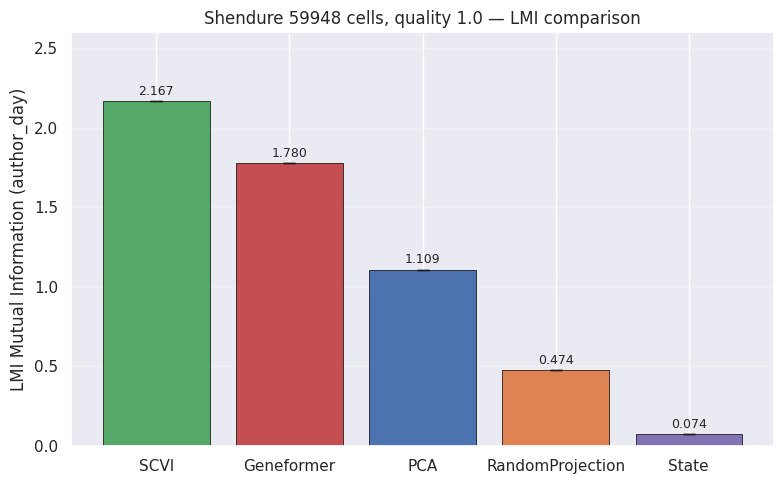

In [25]:
colors = {"PCA": "#4C72B0", "RandomProjection": "#DD8452",
          "SCVI": "#55A868", "Geneformer": "#C44E52", "State": "#8172B3"}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(
    scores_agg["Algorithm"], scores_agg["mean_lmi"],
    yerr=scores_agg["std_lmi"],
    capsize=4,
    color=[colors.get(a, "#999") for a in scores_agg["Algorithm"]],
    edgecolor="black", linewidth=0.5,
)

for bar, mean, std, n in zip(bars, scores_agg["mean_lmi"], scores_agg["std_lmi"], scores_agg["n_seeds"]):
    label = f"{mean:.3f}"
    if n > 1:
        label += f"\n\u00b1{std:.3f} (n={n})"
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + std + 0.02,
            label, ha="center", va="bottom", fontsize=9)

ax.set_ylabel("LMI Mutual Information (author_day)")
ax.set_title(f"Shendure {SIZE} cells, quality {QUALITY} \u2014 LMI comparison")
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, (scores_agg["mean_lmi"] + scores_agg["std_lmi"]).max() * 1.2)
fig.tight_layout()
plt.show()

## 7. UMAP of State embeddings

Running UMAP on 10000 cells, 256 dims


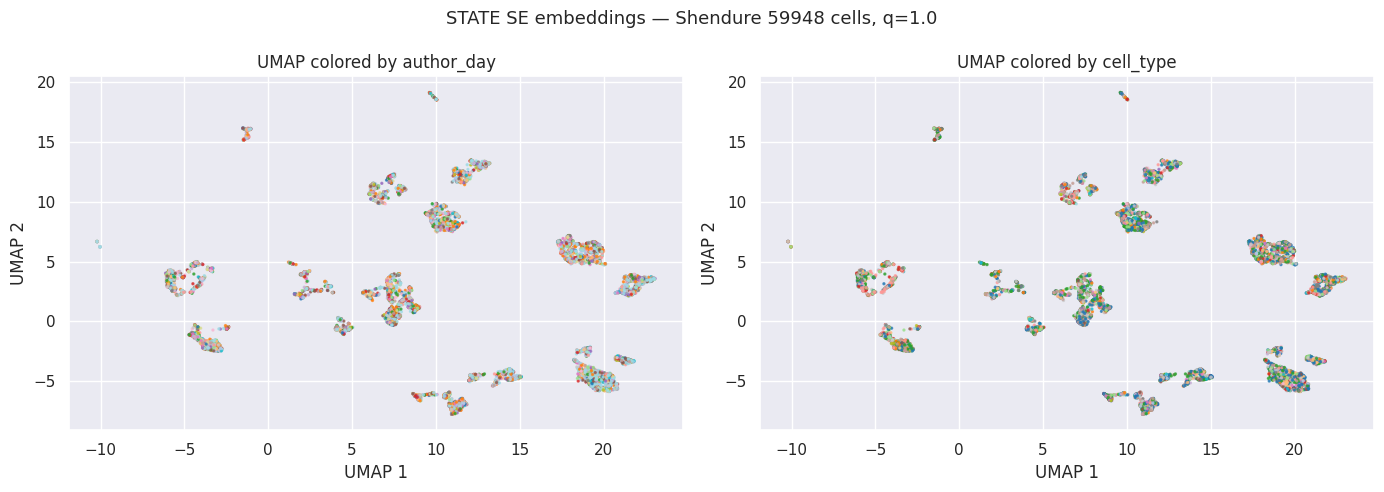

In [26]:
test_h5ad = model.test_data_path / "preprocessed.h5ad"
adata_test = ad.read_h5ad(test_h5ad)

max_cells = 10_000
if embeddings.shape[0] > max_cells:
    rng = np.random.default_rng(42)
    idx = rng.choice(embeddings.shape[0], max_cells, replace=False)
    emb_sub = embeddings[idx]
    obs_sub = adata_test.obs.iloc[idx]
else:
    emb_sub = embeddings
    obs_sub = adata_test.obs

print(f"Running UMAP on {emb_sub.shape[0]} cells, {emb_sub.shape[1]} dims")
reducer = umap.UMAP(n_components=2, random_state=42, n_jobs=1)
umap_coords = reducer.fit_transform(emb_sub)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Color by author_day
ct = obs_sub["author_day"].astype("category")
ct_codes = ct.cat.codes.values
sc0 = axes[0].scatter(umap_coords[:, 0], umap_coords[:, 1],
                       c=ct_codes, cmap="tab20", s=2, alpha=0.7)
axes[0].set_title("UMAP colored by author_day")
axes[0].set_xlabel("UMAP 1"); axes[0].set_ylabel("UMAP 2")

# Color by cell_type
ct2 = obs_sub["cell_type"].astype("category")
ct2_codes = ct2.cat.codes.values
sc1 = axes[1].scatter(umap_coords[:, 0], umap_coords[:, 1],
                       c=ct2_codes, cmap="tab20", s=2, alpha=0.7)
axes[1].set_title("UMAP colored by cell_type")
axes[1].set_xlabel("UMAP 1"); axes[1].set_ylabel("UMAP 2")

fig.suptitle(f"STATE SE embeddings \u2014 Shendure {SIZE} cells, q={QUALITY}", fontsize=13)
fig.tight_layout()
plt.show()